In [1]:
%maven org.knowm.xchart:xchart:3.8.0
%maven com.opencsv:opencsv:5.7.1

P(buena | Documentary    ) =  70.3%  (355/505 películas)
P(buena | History        ) =  52.1%  (428/822 películas)
P(buena | Animation      ) =  52.0%  (827/1589 películas)
P(buena | War            ) =  50.7%  (292/576 películas)
P(buena | Music          ) =  45.5%  (267/587 películas)
P(buena | Drama          ) =  39.6%  (3134/7913 películas)
P(buena | TV Movie       ) =  33.9%  (133/392 películas)
P(buena | Fantasy        ) =  33.9%  (597/1761 películas)
P(buena | Romance        ) =  32.6%  (953/2925 películas)
P(buena | Family         ) =  32.5%  (604/1856 películas)
P(buena | Western        ) =  32.5%  (98/302 películas)
P(buena | Adventure      ) =  30.9%  (755/2443 películas)
P(buena | Crime          ) =  30.7%  (749/2437 películas)
P(buena | Mystery        ) =  24.8%  (369/1489 películas)
P(buena | Action         ) =  23.8%  (869/3654 películas)
P(buena | Comedy         ) =  23.3%  (1536/6593 películas)
P(buena | Science Fiction) =  22.5%  (411/1826 películas)
P(buena | Thriller 

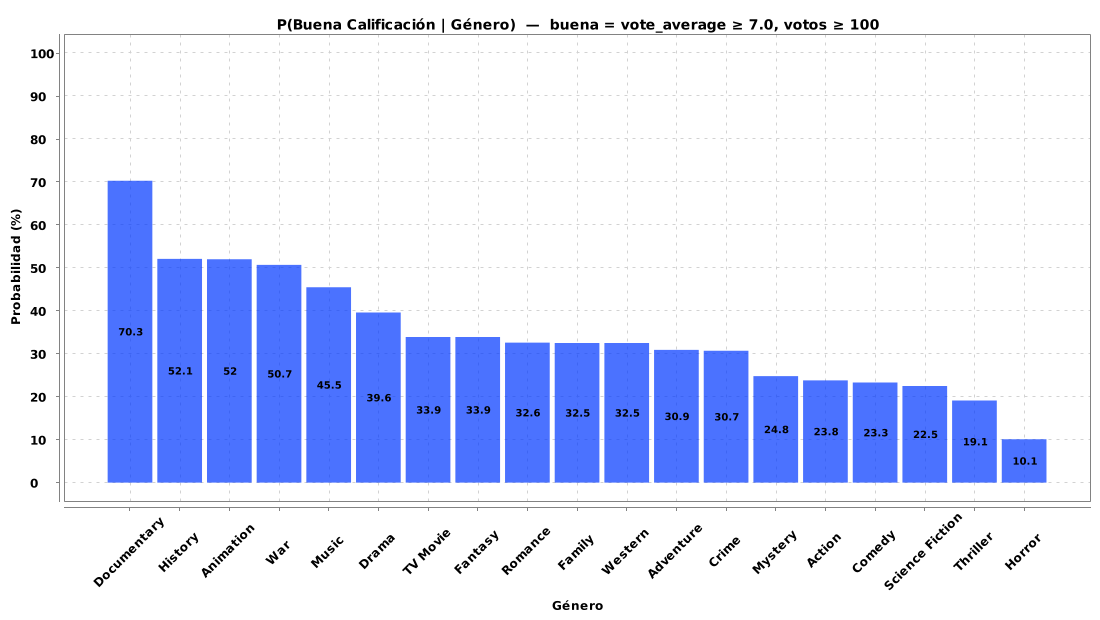

In [4]:
import org.knowm.xchart.*;
import org.knowm.xchart.style.Styler;
import com.opencsv.CSVReader;
import com.opencsv.CSVReaderBuilder;
import java.io.FileReader;
import java.util.*;

// ── 1. LEER CSV ──────────────────────────────────────────────
String ruta = "/workspaces/Ordenamiento-Manejo-de-colisiones-y-an-lisis-de-datos-en-Java/movies.csv";

List<String[]> filas;
String[] encabezados;

try (CSVReader reader = new CSVReaderBuilder(new FileReader(ruta)).build()) {
    filas = reader.readAll();
}
encabezados = filas.get(0);
filas = filas.subList(1, filas.size());

// Buscar índices
int idxGenres = -1, idxVoteAvg = -1, idxVoteCount = -1;
for (int i = 0; i < encabezados.length; i++) {
    String col = encabezados[i].trim().toLowerCase();
    if (col.equals("genres"))       idxGenres   = i;
    if (col.equals("vote_average")) idxVoteAvg  = i;
    if (col.equals("vote_count"))   idxVoteCount = i;
}

// ── 2. CALCULAR PROBABILIDAD CONDICIONAL ─────────────────────
// P(buena calificación | género)
// "buena" = vote_average >= 7.0 con al menos 100 votos

Map<String, Integer> totalPorGenero = new LinkedHashMap<>();
Map<String, Integer> buenasPorGenero = new LinkedHashMap<>();

for (String[] fila : filas) {
    try {
        double avg   = Double.parseDouble(fila[idxVoteAvg].trim());
        double count = Double.parseDouble(fila[idxVoteCount].trim());
        
        if (count < 100) continue; // ignorar películas poco votadas
        
        String[] generos = fila[idxGenres].split(",");
        for (String g : generos) {
            String genero = g.trim();
            if (genero.isEmpty()) continue;
            
            totalPorGenero.merge(genero, 1, Integer::sum);
            if (avg >= 7.0) {
                buenasPorGenero.merge(genero, 1, Integer::sum);
            }
        }
    } catch (Exception e) { /* saltamos filas malas */ }
}

// ── 3. CALCULAR Y ORDENAR PROBABILIDADES ─────────────────────
List<String>  generos       = new ArrayList<>();
List<Double>  probabilidades = new ArrayList<>();

// Filtrar géneros con al menos 50 películas y ordenar de mayor a menor
totalPorGenero.entrySet().stream()
    .filter(e -> e.getValue() >= 50)
    .sorted((a, b) -> {
        double probA = buenasPorGenero.getOrDefault(a.getKey(), 0) * 100.0 / a.getValue();
        double probB = buenasPorGenero.getOrDefault(b.getKey(), 0) * 100.0 / b.getValue();
        return Double.compare(probB, probA); // descendente
    })
    .forEach(e -> {
        double prob = buenasPorGenero.getOrDefault(e.getKey(), 0) * 100.0 / e.getValue();
        generos.add(e.getKey());
        probabilidades.add(prob);
        System.out.printf("P(buena | %-15s) = %5.1f%%  (%d/%d películas)%n",
            e.getKey(), prob,
            buenasPorGenero.getOrDefault(e.getKey(), 0),
            e.getValue());
    });

// Redondear probabilidades a 1 decimal
List<Double> probabilidadesRedondeadas = new ArrayList<>();
for (double p : probabilidades) {
    probabilidadesRedondeadas.add(Math.round(p * 10.0) / 10.0);
}

// ── 4. CONSTRUIR GRÁFICO ──────────────────────────────────────
CategoryChart grafico = new CategoryChartBuilder()
    .width(1100)
    .height(620)
    .title("P(Buena Calificación | Género)  —  buena = vote_average ≥ 7.0, votos ≥ 100")
    .xAxisTitle("Género")
    .yAxisTitle("Probabilidad (%)")
    .build();

grafico.getStyler().setXAxisLabelRotation(45);
grafico.getStyler().setLegendVisible(false);
grafico.getStyler().setHasAnnotations(true);
grafico.getStyler().setYAxisMax(100.0);
grafico.getStyler().setAnnotationsFont(new java.awt.Font("Arial", java.awt.Font.BOLD, 10));
grafico.getStyler().setChartBackgroundColor(java.awt.Color.WHITE);

grafico.addSeries("Probabilidad (%)", generos, probabilidadesRedondeadas);

BitmapEncoder.getBufferedImage(grafico)